#1 🛠️ Preparación de los Datos

##1.1 Extracción del Archivo Tratado

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/popex404/Desafio-Telecom-X-parte2/refs/heads/main/clientes%20(1).csv"
clientes = pd.read_csv(url)
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   bool   
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   bool   
 4   Partner           7043 non-null   bool   
 5   Dependents        7043 non-null   bool   
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   bool   
 8   MultipleLines     7043 non-null   bool   
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   bool   
 11  OnlineBackup      7043 non-null   bool   
 12  DeviceProtection  7043 non-null   bool   
 13  TechSupport       7043 non-null   bool   
 14  StreamingTV       7043 non-null   bool   
 15  StreamingMovies   7043 non-null   bool   
 16  Contract          7043 non-null   object 


##1.2 Eliminación de Columnas Irrelevantes

In [2]:
clientes = clientes.drop(columns=["customerID"])
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7043 non-null   bool   
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   bool   
 3   Partner           7043 non-null   bool   
 4   Dependents        7043 non-null   bool   
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   bool   
 7   MultipleLines     7043 non-null   bool   
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   bool   
 10  OnlineBackup      7043 non-null   bool   
 11  DeviceProtection  7043 non-null   bool   
 12  TechSupport       7043 non-null   bool   
 13  StreamingTV       7043 non-null   bool   
 14  StreamingMovies   7043 non-null   bool   
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   bool   


##1.3 Encoding

In [3]:
clientes.describe()

,tenure,Charges.Monthly,Charges.Total,Charges.Daily
count,7043.000000,7043.000000,7032.000000,7043.000000
mean,32.371149,64.761692,2283.300441,2.127521
std,24.559481,30.090047,2266.771362,0.988435
min,0.000000,18.250000,18.800000,0.600000
25%,9.000000,35.500000,401.450000,1.170000
50%,29.000000,70.350000,1397.475000,2.310000
75%,55.000000,89.850000,3794.737500,2.950000
max,72.000000,118.750000,8684.800000,3.900000


In [4]:
clientes.describe(include='O')

,gender,InternetService,Contract,PaymentMethod
count,7043,7043,7043,7043
unique,2,3,3,4
top,Male,Fiber optic,Month-to-month,Electronic check
freq,3555,3096,3875,2365


In [5]:
def transformar_binario(df, columna):
    # Validar que df sea un DataFrame
    if not isinstance(df, pd.DataFrame):
        raise TypeError("El argumento 'df' debe ser un DataFrame de pandas.")

    # Si columna es string, convertirlo a lista para unificar el manejo
    if isinstance(columna, str):
        columnas = [columna]
    elif isinstance(columna, list):
        columnas = columna
    else:
        raise TypeError("El argumento 'columna' debe ser una cadena o una lista de cadenas.")

    for col in columnas:
        # Verificar que la columna exista en el DataFrame
        if col not in df.columns:
            raise ValueError(f"La columna '{col}' no existe en el DataFrame.")

        # Obtener los valores únicos de la columna
        valores_unicos = df[col].dropna().unique()

        # Validar que tenga exactamente 2 valores distintos (sin contar NaN)
        if len(valores_unicos) != 2:
            raise ValueError(f"La columna '{col}' no tiene exactamente 2 valores únicos.")

        # Reemplazar True por 1 y False por 0
        df[col] = df[col].replace({False: 0, True: 1})

    return df

test_cliente = clientes.copy()
test_cliente = transformar_binario(test_cliente, 'Churn')
test_cliente = transformar_binario(test_cliente, ['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling'])
test_cliente['gender'] = test_cliente['gender'].replace({'Female': 0, 'Male': 1})
test_cliente.sample(3)

/tmp/ipython-input-375736913.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({False: 0, True: 1})
/tmp/ipython-input-375736913.py:34: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_cliente['gender'] = test_cliente['gender'].replace({'Female': 0, 'Male': 1})


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Charges.Daily
4801,0,1,0,0,0,19,1,0,No,0,...,0,0,0,0,One year,1,Credit card (automatic),19.70,386.50,0.65
5544,0,1,0,1,0,3,1,0,No,0,...,0,0,0,0,Month-to-month,0,Bank transfer (automatic),20.00,49.65,0.66
6660,0,1,0,1,0,71,1,1,Fiber optic,0,...,1,1,1,1,One year,1,Bank transfer (automatic),113.15,7953.25,3.72


In [6]:
#Arreglar las columnas categóricas

categoricas = ['InternetService','Contract','PaymentMethod']
pd.get_dummies(data=test_cliente,columns=categoricas, dtype=int).head()

datos_codificados =pd.get_dummies(data=test_cliente,columns=categoricas, dtype=int)
datos_codificados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Churn                                    7043 non-null   int64  
 1   gender                                   7043 non-null   int64  
 2   SeniorCitizen                            7043 non-null   int64  
 3   Partner                                  7043 non-null   int64  
 4   Dependents                               7043 non-null   int64  
 5   tenure                                   7043 non-null   int64  
 6   PhoneService                             7043 non-null   int64  
 7   MultipleLines                            7043 non-null   int64  
 8   OnlineSecurity                           7043 non-null   int64  
 9   OnlineBackup                             7043 non-null   int64  
 10  DeviceProtection                         7043 no

In [7]:
correlation_matrix = datos_codificados.corr(numeric_only=True)
correlation_pairs = correlation_matrix.abs().unstack()

# Eliminar autocorrelaciones (correlación de una variable consigo misma)
correlation_pairs = correlation_pairs[correlation_pairs.index.get_level_values(0) != correlation_pairs.index.get_level_values(1)]

# Eliminar pares duplicados (A,B) y (B,A)
correlation_pairs = correlation_pairs.drop_duplicates()
top_correlations = correlation_pairs.sort_values(ascending=False)
print(top_correlations.head(20))

Charges.Monthly          Charges.Daily                  0.999996
tenure                   Charges.Total                  0.825880
Charges.Monthly          InternetService_Fiber optic    0.787066
Charges.Daily            InternetService_Fiber optic    0.787049
Charges.Monthly          InternetService_No             0.763557
Charges.Daily            InternetService_No             0.763513
Charges.Total            Charges.Daily                  0.651102
Charges.Monthly          Charges.Total                  0.651065
tenure                   Contract_Month-to-month        0.645561
InternetService_DSL      InternetService_Fiber optic    0.640987
StreamingTV              Charges.Monthly                0.629603
                         Charges.Daily                  0.629601
StreamingMovies          Charges.Daily                  0.627429
                         Charges.Monthly                0.627429
Contract_Month-to-month  Contract_Two year              0.622633
                         

In [8]:
datos_codificados = datos_codificados.drop(columns=["Charges.Monthly"])

##1.4 Verificación de la Proporción de Cancelación (Churn)

In [9]:
datos_codificados.value_counts('Churn')

,count
Churn,
0,5174
1,1869


#2 🎯 Correlación y Selección de Variables

##2.1 Análisis de Correlación

In [10]:
correlation_matrix = datos_codificados.corr(numeric_only=True)
correlation_pairs = correlation_matrix.abs().unstack()

# Eliminar autocorrelaciones
correlation_pairs = correlation_pairs[correlation_pairs.index.get_level_values(0) != correlation_pairs.index.get_level_values(1)]

# Eliminar pares duplicados
correlation_pairs = correlation_pairs.drop_duplicates()

# Filtrar solo los pares donde 'Churn' está presente
churn_pairs = correlation_pairs[
    (correlation_pairs.index.get_level_values(0) == 'Churn') |
    (correlation_pairs.index.get_level_values(1) == 'Churn')
]

# Ordenar por valor absoluto de correlación
top_churn_correlations = churn_pairs.sort_values(ascending=False)

# Mostrar los top 20
print(top_churn_correlations)

Churn  Contract_Month-to-month                    0.405103
       tenure                                     0.352229
       InternetService_Fiber optic                0.308020
       Contract_Two year                          0.302253
       PaymentMethod_Electronic check             0.301919
       InternetService_No                         0.227890
       Charges.Total                              0.199484
       Charges.Daily                              0.193317
       PaperlessBilling                           0.191825
       Contract_One year                          0.177820
       OnlineSecurity                             0.171226
       TechSupport                                0.164674
       Dependents                                 0.164221
       SeniorCitizen                              0.150889
       Partner                                    0.150448
       PaymentMethod_Credit card (automatic)      0.134302
       InternetService_DSL                        0.1242

##2.2 Análisis Dirigido

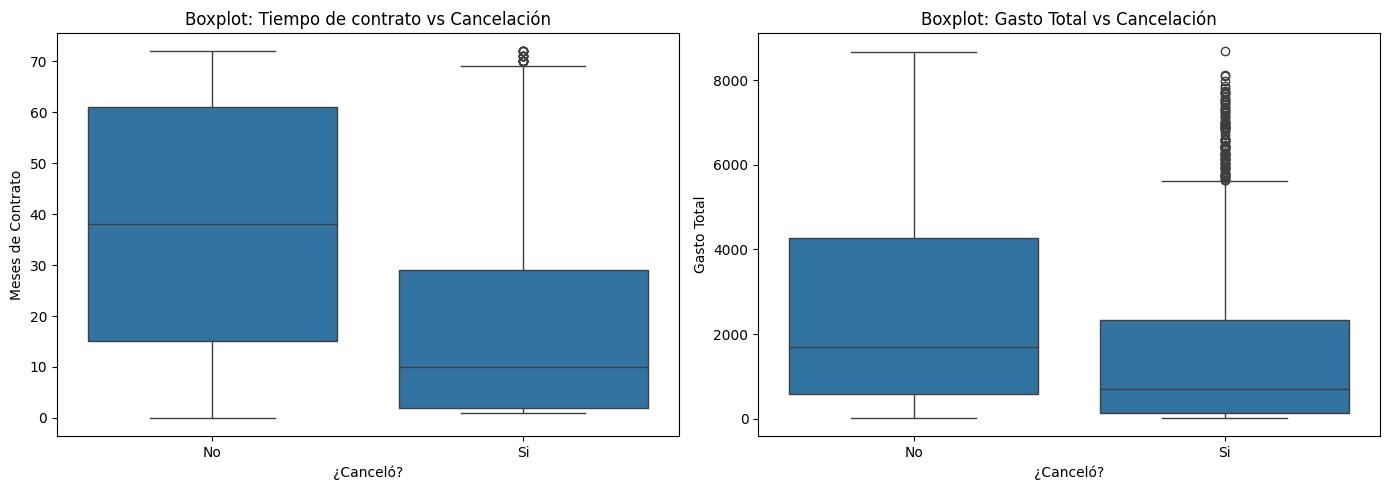

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=datos_codificados,
    x=datos_codificados['Churn'].map({0: 'No', 1: 'Si'}),
    y='tenure',
    ax=axes[0]
)
axes[0].set_title("Boxplot: Tiempo de contrato vs Cancelación")
axes[0].set_ylabel("Meses de Contrato")
axes[0].set_xlabel("¿Canceló?")

sns.boxplot(
    data=datos_codificados,
    x=datos_codificados['Churn'].map({0: 'No', 1: 'Si'}),
    y='Charges.Total',
    ax=axes[1]
)
axes[1].set_title("Boxplot: Gasto Total vs Cancelación")
axes[1].set_ylabel("Gasto Total")
axes[1].set_xlabel("¿Canceló?")

plt.tight_layout()
plt.show()

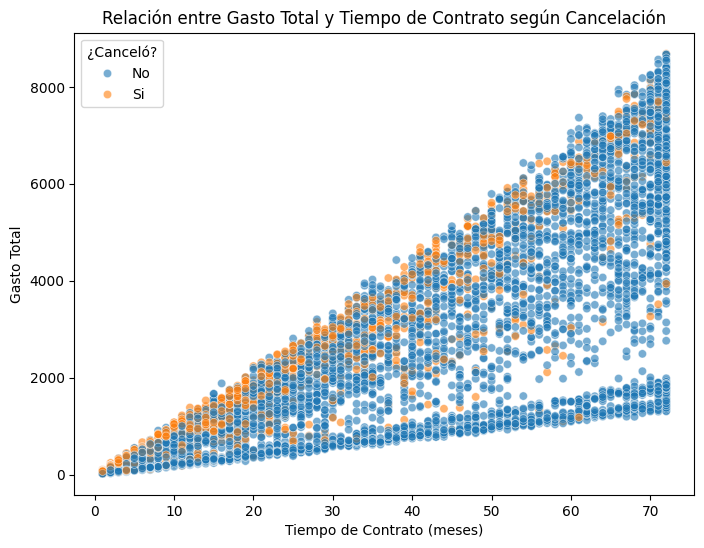

In [12]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=datos_codificados, x='tenure', y='Charges.Total', hue=datos_codificados['Churn'].map({0: 'No', 1: 'Si'}), alpha=0.6)
plt.title("Relación entre Gasto Total y Tiempo de Contrato según Cancelación")
plt.xlabel("Tiempo de Contrato (meses)")
plt.ylabel("Gasto Total")
plt.legend(title="¿Canceló?")
plt.show()

#3 🤖 Modelado Predictivo

##3.1 Creación de Modelo

###3.1.1 Modelo Random Forest

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay


def calcular_regresion(y_test,y_pred):
  rmse = mean_squared_error(y_test,y_pred)
  mae= mean_absolute_error(y_test,y_pred)
  r2 = r2_score(y_test,y_pred)
  metricas = {
      'RMSE':round(rmse**(1/2),4),
      'MAE': round(mae,4),
      'R2': round(r2,4)
  }
  return metricas


X = datos_codificados.drop(['Churn'],axis=1)
y = datos_codificados['Churn']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

modelo = RandomForestRegressor(max_depth=5, random_state=33)
modelo.fit(X_train,y_train)
ypred = modelo.predict(X_test)
resultados_rf = calcular_regresion(y_test,ypred)
resultados_rf

{'RMSE': 0.3716, 'MAE': 0.2734, 'R2': 0.2835}

In [14]:
importances = modelo.feature_importances_
feature_importances = pd.DataFrame({'Features':X.columns,'Importances':(importances*100).round(2)}).sort_values('Importances',ascending=False)
feature_importances

,Features,Importances
19,Contract_Month-to-month,47.56
4,tenure,15.96
17,InternetService_Fiber optic,12.93
15,Charges.Daily,7.08
14,Charges.Total,6.83
24,PaymentMethod_Electronic check,1.87
5,PhoneService,1.34
20,Contract_One year,0.86
18,InternetService_No,0.81
11,StreamingTV,0.78


In [15]:
resultados = pd.DataFrame(index=['RMSE','MAE','R2'])
model_features = RandomForestRegressor(max_depth=5,random_state=42)
ct_features = [i if i != 0 else 1 for i in range(0,35,5)]

for i in ct_features:
  selected_features = feature_importances['Features'].values[:i]
  X_train_sel = X_train[selected_features]
  X_test_sel = X_test[selected_features]
  model_features.fit(X_train_sel, y_train)
  y_pred = model_features.predict(X_test_sel)
  metricas = calcular_regresion(y_test,y_pred)
  resultados[i] = list(metricas.values())

resultados

,1,5,10,15,20,25,30
RMSE,0.4046,0.3742,0.3732,0.3726,0.3720,0.3719,0.3719
MAE,0.3270,0.2754,0.2739,0.2736,0.2735,0.2735,0.2735
R2,0.1509,0.2736,0.2776,0.2800,0.2822,0.2824,0.2824


In [16]:
selected_features = feature_importances['Features'].values[:20]
X_selected_features = X[selected_features]
X_selected_features

X_train,X_test,y_train,y_test = train_test_split(X_selected_features,y,random_state=42)

param_grid = {
              'max_depth':[5,10,15],
              'min_samples_leaf':[1,2,3],
              'min_samples_split':[2,4,6],
              'n_estimators':[100,150,200]
             }



cv = KFold(n_splits=5, shuffle=True, random_state=42)
model_grid = GridSearchCV(RandomForestRegressor(random_state=42),
                          param_grid=param_grid, scoring='r2',
                          cv=cv)

model_grid.fit(X_train,y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 10, 15],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 4, 6],
                         'n_estimators': [100, 150, 200]},
             scoring='r2')

In [17]:
model_grid.best_params_

{'max_depth': 5,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

In [18]:
y_pred_grid = model_grid.predict(X_test)
metricas_model_grid = calcular_regresion(y_test,y_pred_grid)
metricas_model_grid

{'RMSE': 0.3705, 'MAE': 0.2738, 'R2': 0.2889}

In [19]:
resultados['modelo_grid'] = list(metricas_model_grid.values())
resultados

,1,5,10,15,20,25,30,modelo_grid
RMSE,0.4046,0.3742,0.3732,0.3726,0.3720,0.3719,0.3719,0.3705
MAE,0.3270,0.2754,0.2739,0.2736,0.2735,0.2735,0.2735,0.2738
R2,0.1509,0.2736,0.2776,0.2800,0.2822,0.2824,0.2824,0.2889


###3.1.2 Modelo KNN

In [21]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance
import numpy as np


datos_codificados = datos_codificados.dropna()

X2 = datos_codificados.drop(['Churn'],axis=1)
y2 = datos_codificados['Churn']

X_train, X_test, y_train, y_test = train_test_split(X2,y2,test_size=0.3,random_state=42)

normalizacion = MinMaxScaler()
X_train_normalizado = normalizacion.fit_transform(X_train)
X_test_normalizado = normalizacion.transform(X_test)

knn = KNeighborsClassifier()
knn.fit(X_train_normalizado, y_train)

y_pred_grid = knn.predict(X_test_normalizado)

resultado_importancia = permutation_importance(
    knn, X_test_normalizado, y_test, n_repeats=10, random_state=42
)

nombres_columnas = datos_codificados.drop(['Churn'], axis=1).columns
importancias = pd.Series(resultado_importancia.importances_mean, index=nombres_columnas)
importancias = importancias.sort_values(ascending=False)

print("Importancia estimada de variables (por permutación):")
print(importancias)

Importancia estimada de variables (por permutación):
tenure                                     0.009384
Contract_One year                          0.009052
Contract_Month-to-month                    0.007156
Charges.Daily                              0.006730
Charges.Total                              0.006540
gender                                     0.004976
InternetService_Fiber optic                0.004787
InternetService_DSL                        0.004645
SeniorCitizen                              0.004313
PaymentMethod_Electronic check             0.003791
StreamingMovies                            0.003460
PaperlessBilling                           0.003175
TechSupport                                0.002796
PaymentMethod_Mailed check                 0.001991
PaymentMethod_Credit card (automatic)      0.001991
OnlineSecurity                             0.001801
Contract_Two year                          0.000379
InternetService_No                        -0.000521
StreamingTV

              precision    recall  f1-score   support

           0       0.84      0.83      0.83      1554
           1       0.54      0.55      0.54       556

    accuracy                           0.76      2110
   macro avg       0.69      0.69      0.69      2110
weighted avg       0.76      0.76      0.76      2110



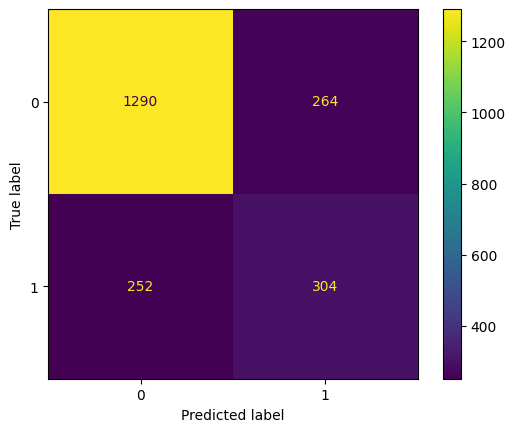

In [22]:
print(classification_report(y_test,y_pred_grid))
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_grid);

              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1301
           1       0.68      0.50      0.57       460

    accuracy                           0.81      1761
   macro avg       0.76      0.71      0.72      1761
weighted avg       0.80      0.81      0.80      1761



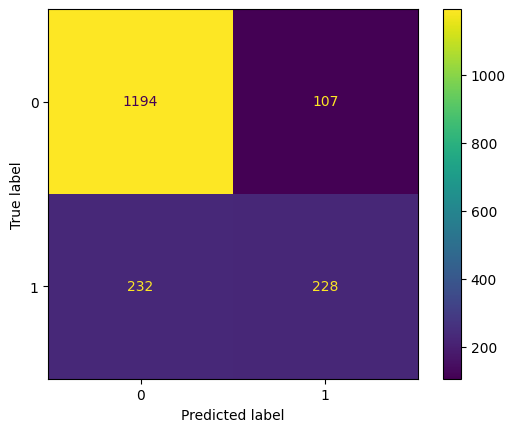

In [20]:
y_pred_grid = (y_pred_grid >= 0.5).astype(int)

print(classification_report(y_test,y_pred_grid))
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_grid);

##3.2 Evaluación del Modelo

###3.2.1 Evaluación del Modelo Random Forest

Con un total de 1194 aciertos de 1301, sin embargo para la prediccion de clientes que abandonaron el modelo solo predice 232 correctamente de 460.

Analizando el reporte es posible ver lo siguiente:

Clientes que no abandonan:

* La precision del modelo en acertar a los clientes que no abandonan es del 84%, por lo que el modelo detectamente correctamente al 92% de los clientes que no abandonan, presentando un F1-score de 0.88.
Clientes que abandonan:
* La precisión del modelo en acertar a los clientes que abandonan es del 68%, haciendo que el modelo detecte correctamente al 50% de los clientes que abandonan, logrando un F1-score del 0.57

###3.2.2 Análisis del Modelo KNN

Un total de 1290 aciertos de 1554, sin embargo para la prediccion de clientes que abandonaron el modelo solo predice 304 correctamente de 556.

Analizando el reporte es posible ver lo siguiente:

* Clientes que no abandonan: La precision del modelo en acertar a los clientes que no abandonan es del 84%, por lo que el modelo detectamente correctamente al 83% de los clientes que no abandonan, presentando un F1-score de 0.83.
* Clientes que abandonan: La precisión del modelo en acertar a los clientes que abandonan es del 54%, haciendo que el modelo detecte correctamente al 55% de los clientes que abandonan, logrando un F1-score del 0.54

#4 📋 Interpretación y Conclusiones

##4.1 Análisi e importancia de las varuables

Métrica	Random Forest	KNN (K-Nearest Neighbors)
Precisión (Churn)
* Random Forest 68%
* KNN 54%

Recall/Exhaustividad (Churn)
* Random Forest 50%
* KNN 55%

F1-Score (Churn)
* Random Forest 0.57
* KNN 0.54

Aciertos Totales
* Random Forest Mayor estabilidad general
* KNN 1290 de 1554 casos


Rendimiento de los Modelos

El análisis compara dos enfoques distintos para predecir qué clientes tienen mayor probabilidad de abandonar el servicio:
* Modelo KNN: Logró un total de 1,290 aciertos de 1,554 casos analizados. Sin embargo, para la predicción específica de abandono, detectó correctamente solo a 304 de 556 clientes (55% de exhaustividad/recall) con una precisión del 54%.
* Modelo Random Forest: Presentó un rendimiento superior en la detección de fugas, con una precisión del 68% para los clientes que abandonan y una capacidad para detectar correctamente al 50% de estos clientes.

Análisis mediante Random Forest (Importancia de Variables)

El modelo de Random Forest jerarquiza las variables basándose en su contribución a la reducción de impureza en las decisiones:
* Contrato (Contract): Los clientes con contratos "Mes a mes" tienen una tasa de cancelación significativamente más alta en comparación con contratos a largo plazo (uno o dos años).
* Antigüedad (Tenure): Existe una correlación inversa entre el tiempo de permanencia y la cancelación; los clientes nuevos son mucho más propensos a abandonar.
* Cargos Mensuales (Monthly Charges): Cargos más elevados suelen estar asociados con una mayor probabilidad de cancelación, sugiriendo sensibilidad al precio.

Análisis mediante KNN (Proximidad y Perfiles)

KNN clasifica a los clientes basándose en la similitud con otros perfiles. Se observó que los clientes que cancelan tienden a compartir características específicas:
* Servicio de Internet de Fibra Óptica: Es un factor recurrente en los perfiles de abandono, posiblemente debido a problemas de estabilidad o costo elevado.
* Método de Pago: El uso de "Electronic check" es predominante entre los clientes que cancelan en comparación con los métodos automáticos.

##4.2 Conclusiones

Identificamos que la cancelación no es aleatoria, sino que responde a barreras de salida bajas y costos percibidos altos.

Factores Críticos Identificados:
* Fragilidad Contractual: El modelo Random Forest confirma que la libertad total del "mes a mes" es nuestro mayor riesgo.
* Sensibilidad al Precio en Fibra: KNN muestra que los usuarios con servicios premium (y más caros) son los más volátiles.

Estrategias de Retención Propuestas:
* Plan de Migración "Lealtad Primero": Ofrecer descuentos significativos o servicios adicionales (como streaming gratuito) a los clientes "Mes a mes" que acepten cambiar a contratos de 1 o 2 años.

Programa de Onboarding Intensivo:
* Dado que el Tenure bajo es un predictor de fuga, crear un flujo de comunicación automática durante los primeros 90 días para asegurar que el cliente sepa usar todos sus servicios.

Incentivo de Pago Automático:
* Bonificación única en la factura para quienes migren de "Cheque Electrónico" a "Cargo Automático". Esto reduce la fricción mensual de ver el cobro y decidir si continuar o no.

Auditoría de Valor en Fibra Óptica:
* Realizar una encuesta de satisfacción técnica específica para los usuarios de fibra. Si la calidad es buena, se recomienda un ajuste en el empaquetado de servicios para que el cargo mensual sea más competitivo.